In [1]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [13]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para exibir gráficos diretamente no notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

In [14]:
# Carregar o novo arquivo CSV
caminho_arquivo = '2025/base_senado_pronta_mineracao.csv'
df_bruto = pd.read_csv(caminho_arquivo, delimiter=';')

# Filtrar apenas o ano de exercício de 2025
df_2025 = df_bruto[df_bruto['ANO EXERCÍCIO'] == 2025].copy()

print(f"Total de registros em 2025: {df_2025.shape[0]}")
df_2025[['LOTAÇÃO EXERCÍCIO', 'HORAS_EXTRAS', 'REM_LIQUIDA', 'MES_REFERENCIA']].head()

Total de registros em 2025: 8937


,LOTAÇÃO EXERCÍCIO,HORAS_EXTRAS,REM_LIQUIDA,MES_REFERENCIA
363,GABINETE DA SENADORA IVETE DA SILVEIRA,0.0,1725.48,1
466,GABINETE DO SENADOR MAGNO MALTA,0.0,2745.10,1
471,GABINETE DO SENADOR MAGNO MALTA,0.0,2198.45,1
472,GABINETE DA LIDERANÇA DA BANCADA FEMININA,0.0,2293.04,1
473,GABINETE DA LIDERANÇA DO PODEMOS,0.0,1725.48,1


In [15]:
X = df_2025[['HORAS_EXTRAS']].values

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K=2, Coeficiente de Silhueta = 0.9890
K=3, Coeficiente de Silhueta = 0.9902
K=4, Coeficiente de Silhueta = 0.9907
K=5, Coeficiente de Silhueta = 0.9916
K=6, Coeficiente de Silhueta = 0.9911
K=7, Coeficiente de Silhueta = 0.9913
K=8, Coeficiente de Silhueta = 0.9917
K=9, Coeficiente de Silhueta = 0.9917
K=10, Coeficiente de Silhueta = 0.9920
K=11, Coeficiente de Silhueta = 0.9920
K=12, Coeficiente de Silhueta = 0.9918
K=13, Coeficiente de Silhueta = 0.9919
K=14, Coeficiente de Silhueta = 0.9922
K=15, Coeficiente de Silhueta = 0.9924
K=16, Coeficiente de Silhueta = 0.9924
K=17, Coeficiente de Silhueta = 0.9927
K=18, Coeficiente de Silhueta = 0.9930
K=19, Coeficiente de Silhueta = 0.9928
K=20, Coeficiente de Silhueta = 0.9928
K=21, Coeficiente de Silhueta = 0.9926
K=22, Coeficiente de Silhueta = 0.9927
K=23, Coeficiente de Silhueta = 0.9930
K=24, Coeficiente de Silhueta = 0.9930
K=25, Coeficiente de Silhueta = 0.9931
K=26, Coeficiente de Silhueta = 0.9930
K=27, Coeficiente de Silhueta = 0

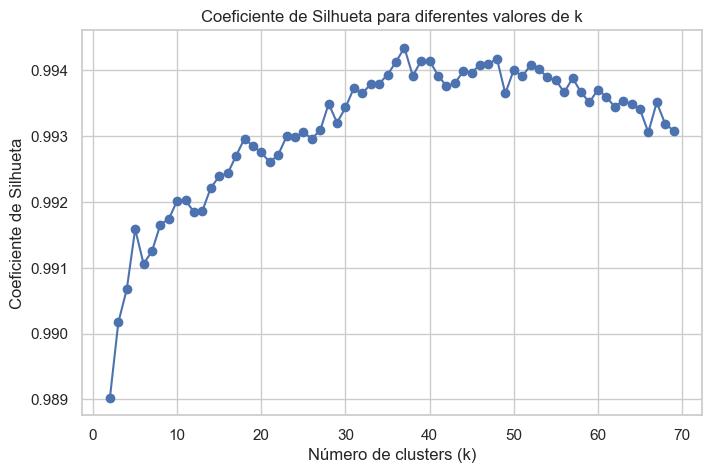

In [22]:
silhouette_scores = []
K = range(2, 70)  # testa de 2 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Coeficiente de Silhueta = {score:.4f}")

# Plotando gráfico da silhueta
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhueta")
plt.title("Coeficiente de Silhueta para diferentes valores de k")
plt.show()

In [23]:
# Escolher o melhor k (maior silhueta)
best_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f"\nNúmero ótimo de clusters: {best_k}")


Número ótimo de clusters: 37


In [ ]:
""" Como a quantidade recomendada matemáticamente para os clusters é 37 e não
iremos conseguir visualmente distinguir essa quantidade alta de grupos iremos optar 
por 5 clusters e analizar esses agrupamentos
"""

In [24]:
# Garantir que as colunas críticas sejam lidas como números (floats)
df_2025['HORAS_EXTRAS'] = pd.to_numeric(df_2025['HORAS_EXTRAS'], errors='coerce').fillna(0)
df_2025['REM_LIQUIDA'] = pd.to_numeric(df_2025['REM_LIQUIDA'], errors='coerce').fillna(0)

# Agrupando por Departamento e Mês para entender a flutuação ao longo de 2025
Agrupado_Mes = df_2025.groupby(['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA']).agg(
    Total_Horas_Extras=('HORAS_EXTRAS', 'sum'),
    Total_Folha=('REM_LIQUIDA', 'sum')
).reset_index()

# Consolidação final por Departamento (Métricas do K-means)
df_departamentos = Agrupado_Mes.groupby('LOTAÇÃO EXERCÍCIO').agg(
    Gasto_Medio_HE=('Total_Horas_Extras', 'mean'),
    Volatilidade_HE=('Total_Horas_Extras', 'std'),
    Gasto_Total_Folha=('Total_Folha', 'mean')
).reset_index()

# Tratamento de valores nulos no Desvio Padrão (Volatilidade)
df_departamentos['Volatilidade_HE'] = df_departamentos['Volatilidade_HE'].fillna(0)

# Cálculo do impacto percentual das Horas Extras na folha do departamento
df_departamentos['Percentual_HE_Na_Folha'] = (df_departamentos['Gasto_Medio_HE'] / df_departamentos['Gasto_Total_Folha']) * 100
df_departamentos['Percentual_HE_Na_Folha'] = df_departamentos['Percentual_HE_Na_Folha'].fillna(0)

# Filtrar apenas departamentos que registraram gastos com HE em 2025
df_analise = df_departamentos[df_departamentos['Gasto_Medio_HE'] > 0].reset_index(drop=True)

print(f"Total de departamentos com Horas Extras em 2025: {df_analise.shape[0]}")
df_analise.head()

Total de departamentos com Horas Extras em 2025: 38


,LOTAÇÃO EXERCÍCIO,Gasto_Medio_HE,Volatilidade_HE,Gasto_Total_Folha,Percentual_HE_Na_Folha
0,BLOCO PARLAM. DEMOCRACIA (MDB/UNIÃO/PODEMOS/PSDB),476.470000,433.039939,32094.713750,1.484575
1,BLOCO PARLAMENTAR VANGUARDA (PL/NOVO),1726.918333,1355.833465,8579.193333,20.129146
2,COORDENAÇÃO DE EVENTOS,35.985000,88.144888,2989.206667,1.203831
3,DIRETORIA-EXECUTIVA DE GOV. CONTRAT. E LICITAT...,119.278889,357.836667,54495.978889,0.218876
4,GABINETE DA DGER,1070.375714,1428.635409,56298.100000,1.901264


In [25]:
# Variáveis que o K-means usará para comparar os setores
atributos = ['Gasto_Medio_HE', 'Volatilidade_HE', 'Percentual_HE_Na_Folha']
X = df_analise[atributos]

# Colocando os dados na mesma escala (Média=0, Desvio Padrão=1)
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X)

print("Dados prontos e normalizados!")

Dados prontos e normalizados!


In [38]:
# Definindo 5 grupos de comportamento
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Treinando o modelo e aplicando os rótulos de grupo 
df_analise['Cluster'] = kmeans.fit_predict(X_escalonado)

# Exibir a média de cada grupo para você entender o perfil de cada um
print("=== Perfil Médio de Cada Cluster ===")
print(df_analise.groupby('Cluster')[atributos].mean())

=== Perfil Médio de Cada Cluster ===
         Gasto_Medio_HE  Volatilidade_HE  Percentual_HE_Na_Folha
Cluster                                                         
0           1022.509660      1341.080761                2.817444
1           3801.998994      2368.758621               11.101114
2           1459.409167       888.630613               20.751601
3           2248.162468      1193.312518                8.557481
4            240.447811       456.394627                1.402782


d:\Nova pasta\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


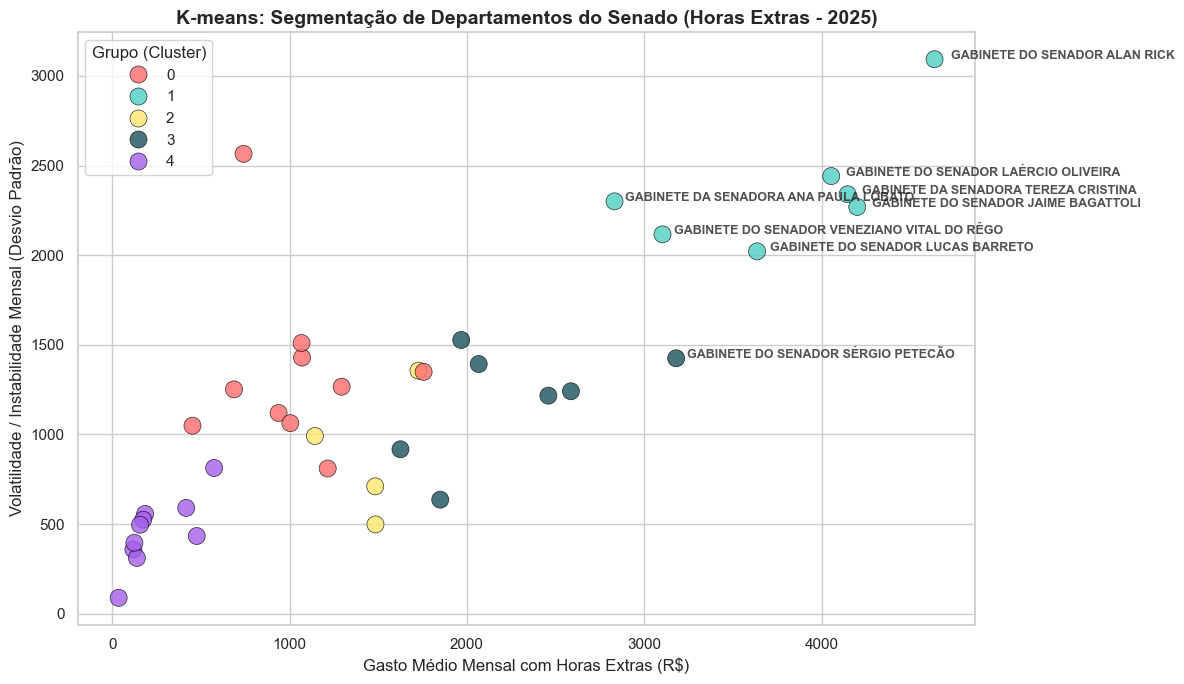

In [39]:
plt.figure(figsize=(12, 7))

# Plot dos pontos de cada departamento com as cores dos clusters

cores_clusters = {
    0: '#FF6B6B',  # Vermelho/Coral (Excelente para o grupo Crítico/Alto Risco)
    1: '#4ECDC4',  # Turquesa/Verde-água (Bom para Risco Baixo)
    2: '#FFE66D',  # Amarelo Pastel (Bom para Risco Médio)
    3: '#1A535C',  # Azul Petróleo Escuro (Ótimo para diferenciar um grupo nulo/zero)
    4: '#A55EEA'   # Roxo Pastel (Para um quinto perfil/outliers)
}

sns.scatterplot(
    data=df_analise,
    x='Gasto_Medio_HE',
    y='Volatilidade_HE',
    hue='Cluster',
    palette=cores_clusters,
    s=150,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Colocar etiquetas nos 8 maiores departamentos para melhor leitura
top_gastos = df_analise.nlargest(8, 'Gasto_Medio_HE')
for idx, row in top_gastos.iterrows():
    plt.text(
        row['Gasto_Medio_HE'] * 1.02,
        row['Volatilidade_HE'],
        row['LOTAÇÃO EXERCÍCIO'],
        fontsize=9,
        fontweight='semibold',
        alpha=0.8
    )

plt.title('K-means: Segmentação de Departamentos do Senado (Horas Extras - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Gasto Médio Mensal com Horas Extras (R$)', fontsize=12)
plt.ylabel('Volatilidade / Instabilidade Mensal (Desvio Padrão)', fontsize=12)
plt.legend(title='Grupo (Cluster)')
plt.tight_layout()
plt.show()

In [34]:
# Criar tabela final ordenada pelo grupo e valor de gasto
relatorio_final = df_analise[['Cluster', 'LOTAÇÃO EXERCÍCIO', 'Gasto_Medio_HE', 'Percentual_HE_Na_Folha']].sort_values(by=['Cluster', 'Percentual_HE_Na_Folha'], ascending=[True, False])

# Exibe o topo da lista estruturada
relatorio_final.head(30)

,Cluster,LOTAÇÃO EXERCÍCIO,Gasto_Medio_HE,Percentual_HE_Na_Folha
19,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR JAYME CAMPOS,1484.478333,22.331316
17,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR IRAJÁ,1483.200000,21.129555
1,"KMeans(n_clusters=37, n_init=10, random_state=42)",BLOCO PARLAMENTAR VANGUARDA (PL/NOVO),1726.918333,20.129146
12,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DA SENADORA TEREZA CRISTINA,4147.243636,19.815991
16,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR FERNANDO FARIAS,1143.040000,19.416385
18,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR JAIME BAGATTOLI,4201.556667,15.394455
8,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DA SENADORA ANA PAULA LOBATO,2832.685833,12.540284
28,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR STYVENSON VALENTIM,2459.667273,12.097499
30,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR VANDERLAN CARDOSO,1625.451667,10.102967
26,"KMeans(n_clusters=37, n_init=10, random_state=42)",GABINETE DO SENADOR PEDRO CHAVES,1849.762500,9.846020
